# What the local model says after an automation displacement

Capital and the tax rate are inherited when the automation state moves. They adjust only over time. A local linear-quadratic approximation makes that propagation transparent: the automation state mean reverts, capital responds with a lag, and gradual tax adjustment feeds back into capital accumulation.

The calculation reproduced here is an exploratory local solution around one interior steady state. It is useful for mechanism and timing, not for a global policy or welfare claim.

## Start with the economic timing

The local system contains two exogenous states and two slow endogenous states.

| State | Economic meaning | Can it jump in this experiment? |
|---|---|---|
| $z$ | productivity state | set to its steady-state value initially |
| $x$ | automation state | displaced by 0.01 units at date zero |
| $\log K$ | log private capital | no |
| $\tau$ | capital-tax rate | no |

After date zero, the experiment switches off further innovations. It therefore traces a conditional-mean adjustment path, not a forecast and not the response to the upstream run's finite-window Brownian shock.

## The local solution representation

After naming the economic quantities, collect their deviations from the interior steady state in

$$
y=
\left(
z-\bar z,\;
x-\bar x,\;
\log(K/\bar K),\;
\tau-\bar\tau
\right)^\top.
$$

The solved local feedback rules reduce the conditional-mean dynamics to $\dot y=A_{\mathrm{cl}}y$. The next cell loads the frozen public matrix and reports the portfolio decomposition from the same local anchor. The units are those of the normalized model.

In [1]:
import json
from pathlib import Path
from IPython.display import Markdown, display

data_path = next(
    path
    for path in (
        Path("notebooks/data/cs001_lq_snapshot.json"),
        Path("data/cs001_lq_snapshot.json"),
    )
    if path.exists()
)
snapshot = json.loads(data_path.read_text(encoding="utf-8"))

portfolio = snapshot["portfolio_decomposition"]
diagnostics = snapshot["diagnostics"]
equation_residuals = [
    diagnostics["riccati_scaled_residual"],
    diagnostics["sylvester_scaled_residual"],
    diagnostics["discounted_lyapunov_scaled_residual"],
]

lines = [
    "| Leading small-risk portfolio component | Model units |",
    "|---|---:|",
    f"| compensated return demand | {portfolio['return_demand_component']:.6f} |",
    f"| fiscal hedge | {portfolio['fiscal_hedge_component']:.6f} |",
    f"| resulting constrained position | {portfolio['leading_constrained_position']:.6f} |",
    "",
    "| Numerical check on the local system | Value |",
    "|---|---:|",
    f"| largest scaled matrix-equation residual | {max(equation_residuals):.2e} |",
    f"| closed-loop stability margin | {diagnostics['closed_loop_stability_margin']:.6f} |",
]
display(Markdown("\n".join(lines)))

| Leading small-risk portfolio component | Model units |
|---|---:|
| compensated return demand | 12.569150 |
| fiscal hedge | -12.122661 |
| resulting constrained position | 0.446489 |

| Numerical check on the local system | Value |
|---|---:|
| largest scaled matrix-equation residual | 1.16e-16 |
| closed-loop stability margin | 0.076028 |

The leading position is the sum of ordinary compensated return demand and a fiscal hedge:

$$
s^{(0)}
=
\underbrace{12.569}_{\text{return demand}}
\;+\;
\underbrace{(-12.123)}_{\text{fiscal hedge}}
=0.446.
$$

At this anchor, fiscal resources already covary positively with the claim. The government therefore uses the hedge term to offset most of the position that expected returns alone would produce. The size of this cancellation is an exploratory model number, not a calibrated estimate.

## Propagation through capital and tax adjustment

Starting from $y(0)=(0,0.01,0,0)^\top$, the path is

$$
y(t)=\exp(A_{\mathrm{cl}}t)y(0).
$$

The matrix exponential propagates the solved local system; it does not explain the economics by itself. In this experiment, automation first changes the return to capital and worker resources. Capital then accumulates gradually. The tax rate initially moves in the opposite direction and later reverses as the capital–tax feedback returns the system toward the steady state.

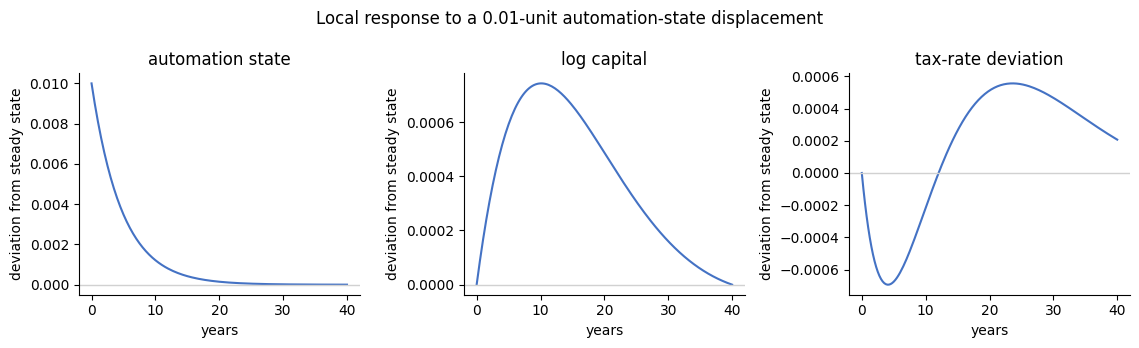

The productivity state remains at zero by construction. All four closed-loop eigenvalues have negative real parts. The slow pair has real part **-0.0760**, so this frozen local path returns toward the steady state.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

system = snapshot["closed_loop_system"]
coordinates = system["coordinates"]
matrix = np.array(system["matrix"], dtype=float)
eigenvalues, eigenvectors = np.linalg.eig(matrix)
inverse_eigenvectors = np.linalg.inv(eigenvectors)

horizons = np.linspace(0.0, 40.0, 161)
initial = np.zeros(4)
initial[coordinates.index("x")] = 0.01
paths = np.array(
    [
        np.real_if_close(
            eigenvectors @ np.diag(np.exp(eigenvalues * horizon))
            @ inverse_eigenvectors @ initial
        ).real
        for horizon in horizons
    ]
)

plotted_coordinates = [
    ("x", "automation state"),
    ("k", "log capital"),
    ("tau_deviation", "tax-rate deviation"),
]

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.5), sharex=True)
for axis, (coordinate, label) in zip(axes, plotted_coordinates):
    index = coordinates.index(coordinate)
    axis.plot(horizons, paths[:, index], color="#4472C4")
    axis.axhline(0, color="0.82", linewidth=1)
    axis.set_title(label)
    axis.set_xlabel("years")
    axis.set_ylabel("deviation from steady state")
    axis.spines[["top", "right"]].set_visible(False)
fig.suptitle("Local response to a 0.01-unit automation-state displacement")
plt.tight_layout()
plt.show()

display(
    Markdown(
        "The productivity state remains at zero by construction. "
        "All four closed-loop eigenvalues have negative real parts. "
        "The slow pair has real part "
        f"**{max(value.real for value in eigenvalues):.4f}**, "
        "so this frozen local path returns toward the steady state."
    )
)

## Reading the path

The automation state decays directly. Capital rises more slowly, peaks after the initial disturbance has already diminished, and then returns. The tax deviation is initially negative and later positive. This reversal comes from the coupled capital–tax dynamics; negative real parts of the eigenvalues alone would not imply a monotone path for either coordinate.

The small equation residuals show that the stored matrices agree internally, and the eigenvalues establish stability of this particular local closed loop. They do not establish feasibility away from the steady state, the accuracy of the approximation near a constraint, or optimality in the nonlinear five-state problem.

## Reproduce and trace

- Public source container: [tai-public-finance at commit 971cab1](https://github.com/Nathan-Barnard/tai-public-finance/tree/971cab12986bce99c23a291fd62a5cde66ffa01a)
- Implementation used for the frozen run: [commit d876a61](https://github.com/Nathan-Barnard/tai-public-finance/tree/d876a61ef593737c2cfbd6f758192c0f390318ab)
- Run: RUN-20260901T194938Z-CS001-d876a61e-01; computation CP001; draft specification CS001; local analytical objects R22 and R23
- Frozen export: notebooks/data/cs001_lq_snapshot.json, assembled only from hash-identified public artifacts
- Environment: upstream uv.lock; Python 3.13.5, NumPy 2.5.2, SciPy 1.18.1, Matplotlib 3.11.1, FP64 CPU

The upstream findings file corrects an earlier claim-access sign-flip description: the reported access/no-claim consumption gap is numerically constant across the saved horizons. This notebook makes no sign-flip claim.

To reproduce the upstream run, use the source commit and command recorded in its run file. Then rebuild the compact export with scripts/refresh_frozen_exports.py and execute this notebook.